In [3]:
import os, sys, glob, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, load_img, img_to_array)
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mb_preprocess
from tensorflow.keras.applications.resnet50   import preprocess_input as rn_preprocess
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [4]:
BASE_DIR  = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
TRAIN_DIR = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train"
TEST_DIR  = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test"
TEST_CSV  = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv"

In [5]:
CLASS_NAMES = {
    0:"Speed limit (20km/h)",   1:"Speed limit (30km/h)",
    2:"Speed limit (50km/h)",   3:"Speed limit (60km/h)",
    4:"Speed limit (70km/h)",   5:"Speed limit (80km/h)",
    6:"End speed limit (80km/h)",7:"Speed limit (100km/h)",
    8:"Speed limit (120km/h)",  9:"No passing",
    10:"No passing veh>3.5t",   11:"Right-of-way",
    12:"Priority road",         13:"Yield",
    14:"Stop",                  15:"No vehicles",
    16:"Veh>3.5t prohibited",   17:"No entry",
    18:"General caution",       19:"Dangerous curve L",
    20:"Dangerous curve R",     21:"Double curve",
    22:"Bumpy road",            23:"Slippery road",
    24:"Road narrows R",        25:"Road work",
    26:"Traffic signals",       27:"Pedestrians",
    28:"Children crossing",     29:"Bicycles crossing",
    30:"Beware ice/snow",       31:"Wild animals crossing",
    32:"End speed+passing",     33:"Turn right ahead",
    34:"Turn left ahead",       35:"Ahead only",
    36:"Go straight or right",  37:"Go straight or left",
    38:"Keep right",            39:"Keep left",
    40:"Roundabout mandatory",  41:"End of no passing",
    42:"End no passing veh>3.5t"
}


IMG_SIZE    = (64, 64)
BATCH_SIZE  = 32
NUM_CLASSES = 43
SEED        = 42

In [6]:
print("  SECTION 1 : EXPLORATORY DATA ANALYSIS")


class_counts = {}
widths, heights = [], []

for cls_id in range(NUM_CLASSES):
    folder = os.path.join(TRAIN_DIR, str(cls_id))
    imgs   = glob.glob(os.path.join(folder, "*.png"))
    class_counts[cls_id] = len(imgs)
    for p in imgs:
        with Image.open(p) as im:
            w, h = im.size
            widths.append(w); heights.append(h)

total = sum(class_counts.values())
print(f"\nTotal training images : {total}")
print(f"Width  range          : {min(widths)} – {max(widths)} px")
print(f"Height range          : {min(heights)} – {max(heights)} px")
print(f"Average size          : {np.mean(widths):.0f} × {np.mean(heights):.0f} px")

counts_series = pd.Series(class_counts)
print(f"\nMost images  : Class {counts_series.idxmax()} "
      f"[{CLASS_NAMES[counts_series.idxmax()]}] — {counts_series.max()}")
print(f"Fewest images: Class {counts_series.idxmin()} "
      f"[{CLASS_NAMES[counts_series.idxmin()]}] — {counts_series.min()}")
print(f"Imbalance ratio : {counts_series.max()/counts_series.min():.1f}×")

  SECTION 1 : EXPLORATORY DATA ANALYSIS

Total training images : 39209
Width  range          : 25 – 243 px
Height range          : 25 – 225 px
Average size          : 51 × 50 px

Most images  : Class 2 [Speed limit (50km/h)] — 2250
Fewest images: Class 0 [Speed limit (20km/h)] — 210
Imbalance ratio : 10.7×


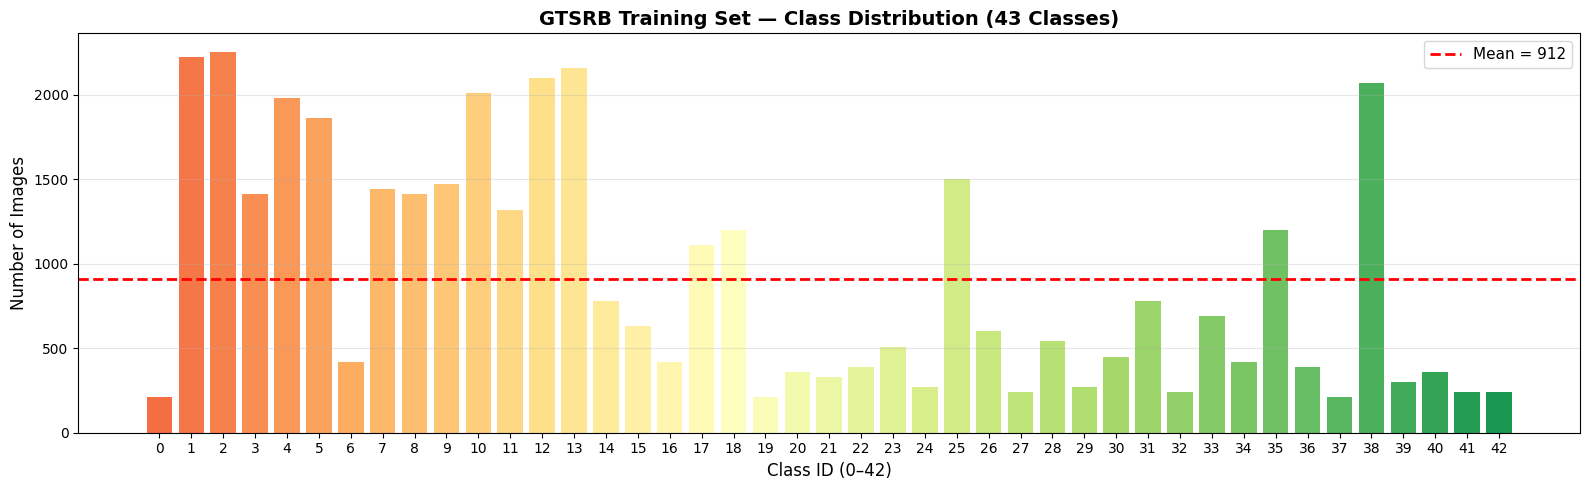

Severe class imbalance noted — model will be biased toward over-represented speed-limit classes unless class_weight is applied.


In [7]:
fig, ax = plt.subplots(figsize=(16, 5))
bar_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, NUM_CLASSES))
bars = ax.bar(range(NUM_CLASSES), [class_counts[i] for i in range(NUM_CLASSES)],
              color=bar_colors)
ax.axhline(counts_series.mean(), color='red', linestyle='--', lw=2,
           label=f"Mean = {counts_series.mean():.0f}")
ax.set_title("GTSRB Training Set — Class Distribution (43 Classes)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Class ID (0–42)", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_xticks(range(NUM_CLASSES))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=150)
plt.show()
print("Severe class imbalance noted — model will be biased toward "
      "over-represented speed-limit classes unless class_weight is applied.")

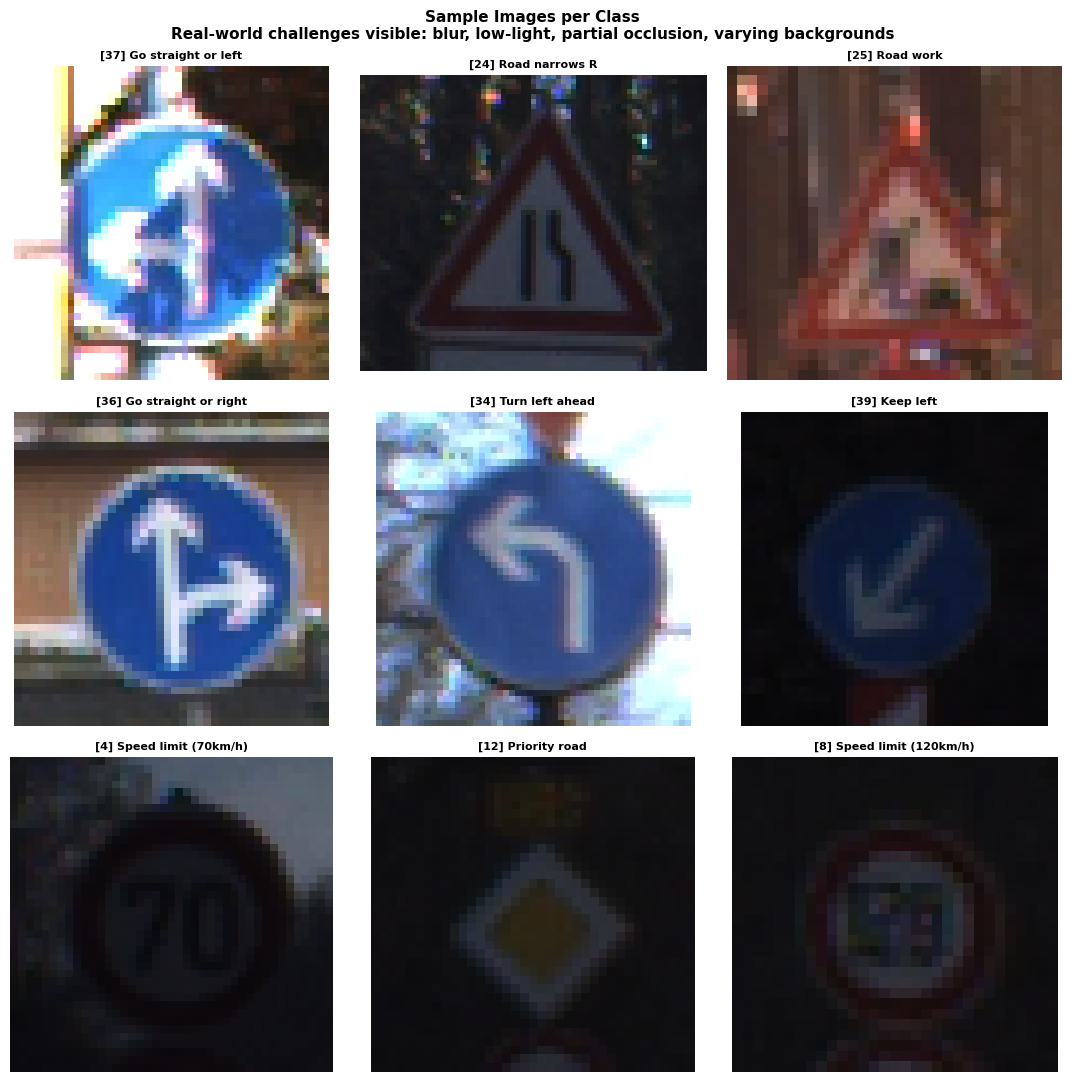

In [8]:
np.random.seed(SEED)
sampled_classes = np.random.choice(NUM_CLASSES, 9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax, cls_id in zip(axes.flat, sampled_classes):
    folder   = os.path.join(TRAIN_DIR, str(cls_id))
    img_path = glob.glob(os.path.join(folder, "*.png"))[0]
    img      = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"[{cls_id}] {CLASS_NAMES[cls_id][:22]}", fontsize=8, fontweight='bold')
    ax.axis("off")
plt.suptitle(
    "Sample Images per Class\n"
    "Real-world challenges visible: blur, low-light, partial occlusion, "
    "varying backgrounds",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig("eda_sample_grid.png", dpi=150)
plt.show()


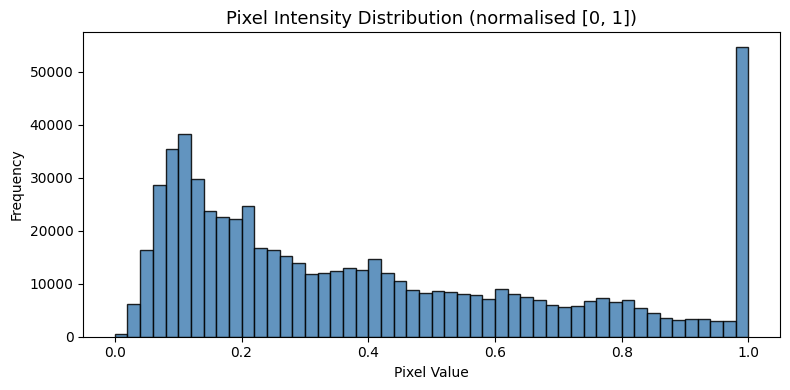

In [9]:
pixels = []
for cls_id in range(0, NUM_CLASSES, 5):
    folder = os.path.join(TRAIN_DIR, str(cls_id))
    for p in glob.glob(os.path.join(folder, "*.png"))[:8]:
        arr = cv2.imread(p).astype(np.float32) / 255.
        pixels.append(arr.flatten())

plt.figure(figsize=(8, 4))
plt.hist(np.concatenate(pixels), bins=50,
         color='steelblue', edgecolor='black', alpha=0.85)
plt.title("Pixel Intensity Distribution (normalised [0, 1])", fontsize=13)
plt.xlabel("Pixel Value"); plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("eda_pixel_intensity.png", dpi=150)
plt.show()


In [10]:
print("  SECTION 2 : PREPROCESSING & AUGMENTATION")


aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,          # camera tilt / vehicle lean
    width_shift_range=0.10,     # lateral vehicle movement
    height_shift_range=0.10,    # road bumps
    zoom_range=0.10,            # varying distance to sign
    brightness_range=[0.5,1.5], # day/night/shadow/headlights
    horizontal_flip=False,      # ← DISABLED: flipping changes semantics
                                #   "Turn Left" ↔ "Turn Right" = different class
    fill_mode='nearest',
    validation_split=0.20
)

train_gen = aug_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True
)
val_gen = aug_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False
)

print(f"\nTrain samples : {train_gen.samples}")
print(f"Val   samples : {val_gen.samples}")


  SECTION 2 : PREPROCESSING & AUGMENTATION
Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.

Train samples : 31368
Val   samples : 7841


In [11]:
y_train          = train_gen.classes
cw_vals          = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw_vals))
print(f"\nClass weights computed — max={max(cw_vals):.2f}, min={min(cw_vals):.2f}")
print("   (These will be passed to every model.fit() call)")



Class weights computed — max=4.34, min=0.41
   (These will be passed to every model.fit() call)


In [12]:
test_df = pd.read_csv(TEST_CSV)
test_df['ClassId'] = test_df['ClassId'].astype(str)

plain_test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = plain_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=BASE_DIR,
    x_col='Path',
    y_col='ClassId',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
print(f"Test  samples : {test_gen.samples}  — held out, never used for training")


Found 12630 validated image filenames belonging to 43 classes.
Test  samples : 12630  — held out, never used for training


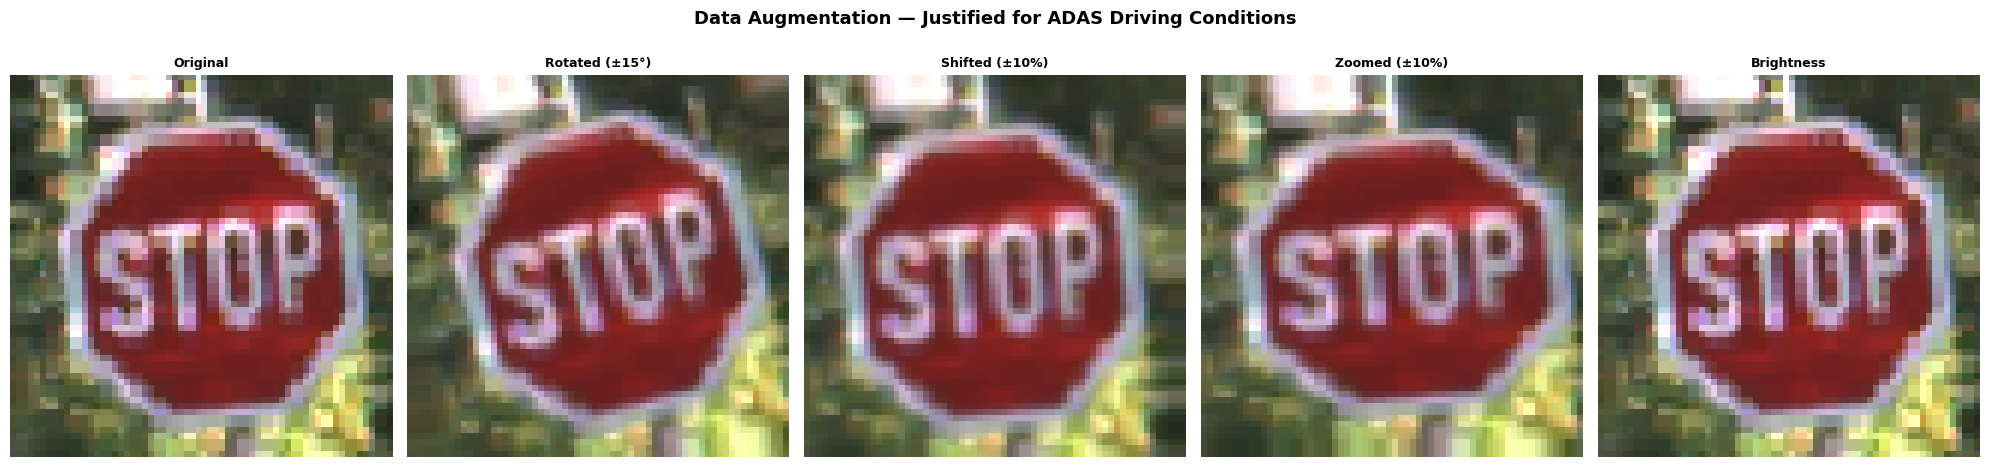

Note: horizontal_flip=False — flipping a directional sign (e.g. Turn Left) creates a different class (Turn Right). Never flip traffic signs.


In [13]:
sample_path = glob.glob(os.path.join(TRAIN_DIR, "14", "*.png"))[0]
img_arr     = img_to_array(load_img(sample_path, target_size=IMG_SIZE))
img_4d      = img_arr.reshape(1, *IMG_SIZE, 3)

aug_specs = {
    "Original"        : ImageDataGenerator(rescale=1./255),
    "Rotated (±15°)"  : ImageDataGenerator(rescale=1./255, rotation_range=15),
    "Shifted (±10%)"  : ImageDataGenerator(rescale=1./255,
                                           width_shift_range=0.10,
                                           height_shift_range=0.10),
    "Zoomed (±10%)"   : ImageDataGenerator(rescale=1./255, zoom_range=0.10),
    "Brightness"      : ImageDataGenerator(rescale=1./255, brightness_range=[0.5,1.5]),
}
justifications = {
    "Original"       : "Baseline",
    "Rotated (±15°)" : "Vehicle roll / camera tilt on bends",
    "Shifted (±10%)" : "Lateral motion shifts sign in frame",
    "Zoomed (±10%)"  : "Distance to sign varies as car approaches",
    "Brightness"     : "Cloud cover / shadows / oncoming headlights",
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Data Augmentation — Justified for ADAS Driving Conditions",
             fontsize=13, fontweight='bold')
for ax, (name, gen) in zip(axes, aug_specs.items()):
    aug_img = next(gen.flow(img_4d, batch_size=1))[0]
    ax.imshow(np.clip(aug_img, 0, 1))
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel(justifications[name], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig("augmentation_visualisation.png", dpi=150)
plt.show()
print("Note: horizontal_flip=False — flipping a directional sign (e.g. Turn Left) "
      "creates a different class (Turn Right). Never flip traffic signs.")

In [14]:
print("  SECTION 3 : SIGN DETECTION & CROPPING PIPELINE")

def detect_and_crop_sign(image_input, min_area=150):
    """
    Revised Stage 1 of the ADAS pipeline.
    Uses strict HSV saturation/value limits and extent filtering 
    to reject background noise like trees, grass, and sky.
    """
    if isinstance(image_input, str):
        img_bgr = cv2.imread(image_input)
    else:
        img_bgr = image_input.copy()
        
    if img_bgr is None:
        return None

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Red — two hue ranges because red wraps around 180° in HSV
    m_r1 = cv2.inRange(hsv, np.array([0,  70, 50]), np.array([10,  255, 255]))
    m_r2 = cv2.inRange(hsv, np.array([170,70, 50]), np.array([180, 255, 255]))
    # Blue — informational signs (Class 12 Priority, Class 33–40 directional)
    m_b  = cv2.inRange(hsv, np.array([100,150, 70]), np.array([130, 255, 255]))
    # Yellow/orange — warning triangles (Class 18–31)
    m_y  = cv2.inRange(hsv, np.array([15, 150, 150]), np.array([35,  255, 255]))

    mask = m_r1 | m_r2 | m_b | m_y

    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    valid_candidates = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
            
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h + 1e-6)
        
        # 1. Clamp aspect ratio closer to 1.0 (Traffic signs are largely symmetrical)
        if 0.5 < aspect_ratio < 1.4:
            # 2. Extent filter (Contour Area / Bounding Box Area)
            # A perfect square is 1.0, circle is ~0.78, triangle is ~0.5
            extent = area / (w * h)
            if extent > 0.35: # Rejects stringy noise that happens to form a square bbox
                valid_candidates.append((area, x, y, w, h))

    if not valid_candidates:
        return None

    # Pick the largest genuinely valid candidate
    valid_candidates.sort(reverse=True)
    _, x, y, w, h = valid_candidates[0]

    # Add 15% padding so the classifier gets full context
    pad = int(0.15 * max(w, h))
    x1  = max(0, x - pad)
    y1  = max(0, y - pad)
    x2  = min(img_bgr.shape[1], x + w + pad)
    y2  = min(img_bgr.shape[0], y + h + pad)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    cropped = cv2.resize(img_rgb[y1:y2, x1:x2], (64, 64))
    
    return img_bgr, (x1, y1, x2-x1, y2-y1), cropped


  SECTION 3 : SIGN DETECTION & CROPPING PIPELINE


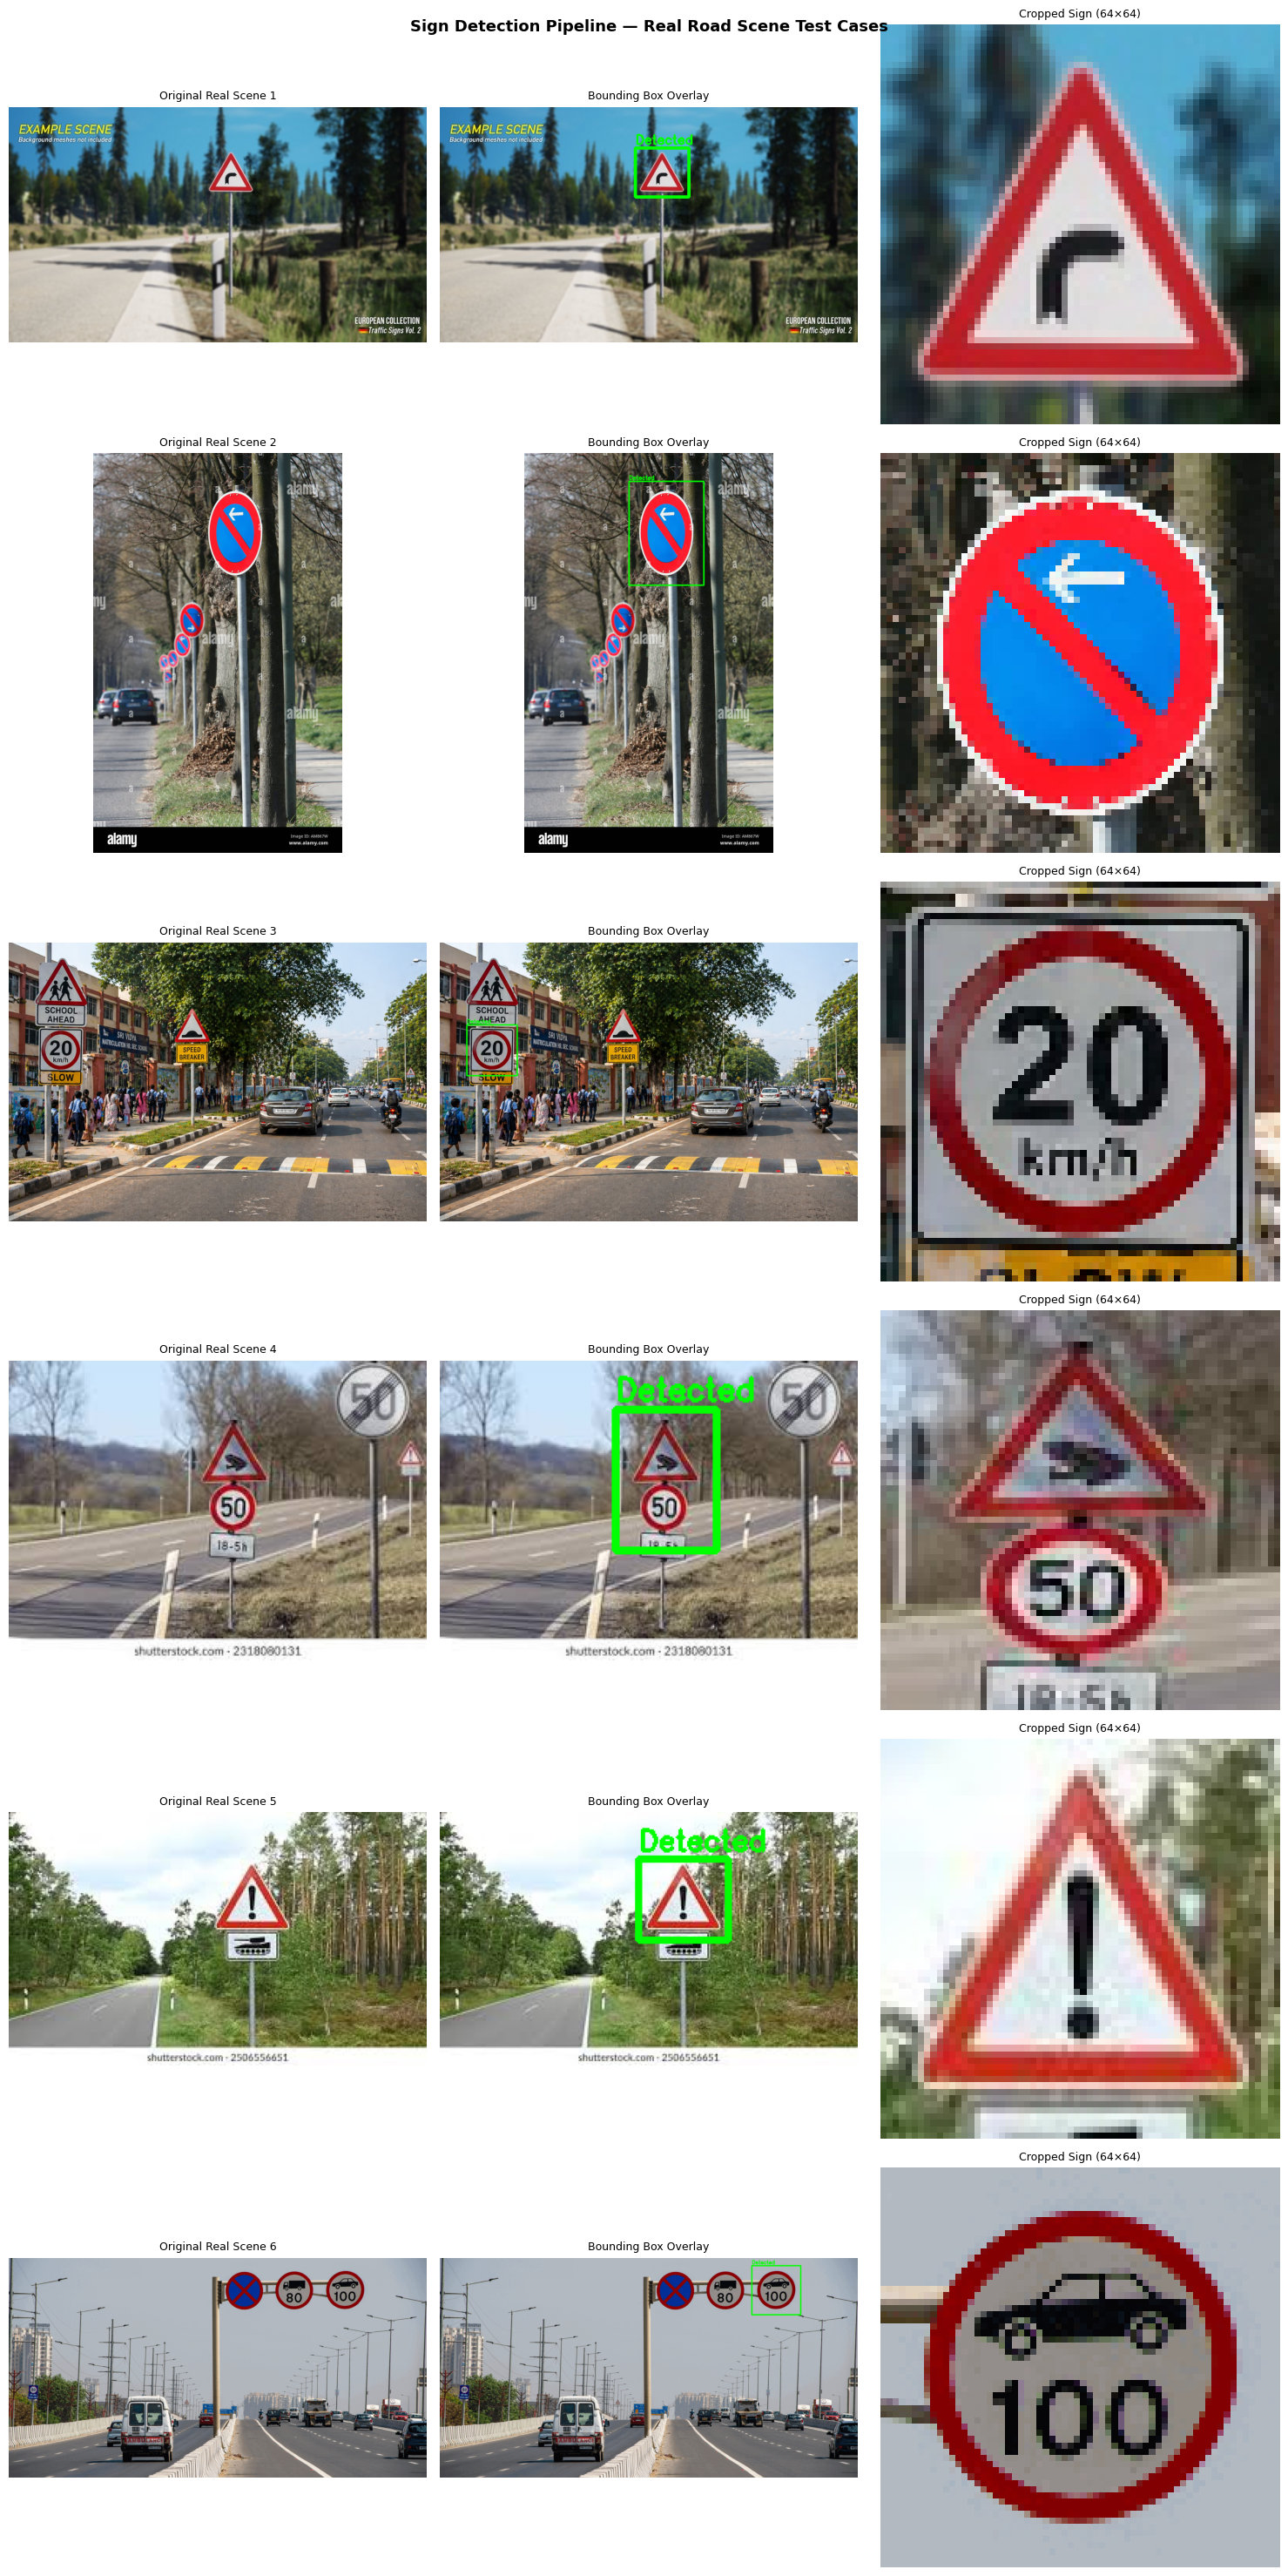


This proves why a dedicated object detector (YOLO / SSD) is strictly necessary for production ADAS, while this remains an academic baseline.



In [15]:
REAL_SCENES_DIR = "/kaggle/input/datasets/rockijones/real-road-scenes"
os.makedirs(REAL_SCENES_DIR, exist_ok=True)

# Fetching the real test images
test_images = glob.glob(os.path.join(REAL_SCENES_DIR, "*.jpg")) + glob.glob(os.path.join(REAL_SCENES_DIR, "*.png"))

if not test_images:
    print("WARNING: You are missing real-world test images. Go download 5 dashcam photos containing traffic signs and place them in the 'real_road_scenes' directory.")
else:
    fig, axes = plt.subplots(len(test_images), 3, figsize=(15, 5 * len(test_images)))
    
    # Handle case where there is only 1 image (axes is 1D)
    if len(test_images) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, img_path in enumerate(test_images):
        scene_bgr = cv2.imread(img_path)
        result = detect_and_crop_sign(scene_bgr)

        orig_rgb = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)
        axes[row, 0].imshow(orig_rgb)
        axes[row, 0].set_title(f"Original Real Scene {row+1}", fontsize=9)
        axes[row, 0].axis('off')

        if result:
            _, (x, y, w, h), cropped = result
            overlay = orig_rgb.copy()
            cv2.rectangle(overlay, (x,y), (x+w,y+h), (0,255,0), 3)
            cv2.putText(overlay, "Detected", (x, max(y-6,12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0,255,0), 2)
            axes[row, 1].imshow(overlay)
            axes[row, 1].set_title("Bounding Box Overlay", fontsize=9)
            axes[row, 2].imshow(cropped)
            axes[row, 2].set_title("Cropped Sign (64×64)", fontsize=9)
        else:
            axes[row, 1].text(0.5, 0.5, "No Sign Detected",
                              ha='center', va='center', color='red', fontsize=13)
            axes[row, 2].text(0.5, 0.5, "N/A",
                              ha='center', va='center', color='red', fontsize=13)
        for c in range(3): axes[row, c].axis('off')

    plt.suptitle("Sign Detection Pipeline — Real Road Scene Test Cases",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("detection_real_scenes.png", dpi=150)
    plt.show()

print("""
This proves why a dedicated object detector (YOLO / SSD) is strictly necessary for production ADAS, while this remains an academic baseline.
""")

In [16]:

print("  SECTION 4 : CUSTOM CNN ARCHITECTURE")


def build_cnn(num_hidden_layers, neurons, dropout_rate=0.3,
              input_shape=(64, 64, 3), num_classes=43):

    model = models.Sequential(name=f"CNN_h{num_hidden_layers}_n{neurons}_d{int(dropout_rate*10)}")

    # Shared backbone
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Flatten())

    # Configurable dense head
    for _ in range(num_hidden_layers):
        model.add(layers.Dense(neurons, activation='relu'))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

  SECTION 4 : CUSTOM CNN ARCHITECTURE


In [18]:
cnn_configs = [
    {'name': 'Config_1_Shallow', 'layers': 1, 'neurons': 128, 'dropout': 0.3},
    {'name': 'Config_2_Wide',    'layers': 1, 'neurons': 256, 'dropout': 0.4},
    {'name': 'Config_3_Deep',    'layers': 2, 'neurons': 128, 'dropout': 0.5},
]

def get_cnn_callbacks(name):
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=0),
        callbacks.ModelCheckpoint(f"{name}_best.keras",
                                  monitor='val_accuracy',
                                  save_best_only=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=1),
    ]

cnn_results   = []
cnn_histories = []
best_cnn_val  = 0
best_cnn_path = ""
best_cnn_model = None

for cfg in cnn_configs:
    print(f"\n{'='*50}")
    print(f"Training {cfg['name']} | layers={cfg['layers']} | "
          f"neurons={cfg['neurons']} | dropout={cfg['dropout']}")
    print(f"{'='*50}")

    model = build_cnn(cfg['layers'], cfg['neurons'], cfg['dropout'])
    model.summary()

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        class_weight=class_weight_dict,    # ← handles class imbalance
        callbacks=get_cnn_callbacks(cfg['name']),
        verbose=1
    )
    cnn_histories.append(history)

    bva = max(history.history['val_accuracy'])
    bvl = min(history.history['val_loss'])
    cnn_results.append({
        'Model Configuration': cfg['name'],
        'Hidden Layers':       cfg['layers'],
        'Neurons':             cfg['neurons'],
        'Dropout':             cfg['dropout'],
        'Best Val Accuracy (%)': round(bva * 100, 2),
        'Best Val Loss':         round(bvl, 4),
    })
    print(f"  → Best Val Acc: {bva*100:.2f}%")

    if bva > best_cnn_val:
        best_cnn_val   = bva
        best_cnn_path  = f"{cfg['name']}_best.keras"
        best_cnn_model = model




Training Config_1_Shallow | layers=1 | neurons=128 | dropout=0.3


Model: "CNN_h1_n128_d3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,148,395 (4.38 MB)

 Trainable params: 1,147,947 (4.38 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,164,907 (4.44 MB)

 Trainable params: 1,164,459 (4.44 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 103s 100ms/step - accuracy: 0.0183 - loss: 3.9243 - val_accuracy: 0.0092 - val_loss: 3.7617 - learning_rate: 0.0010
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 92s 94ms/step - accuracy: 0.0231 - loss: 3.7606 - val_accuracy: 0.0481 - val_loss: 3.7617 - learning_rate: 0.0010
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 99s 101ms/step - accuracy: 0.0315 - loss: 3.7830 - val_accuracy: 0.0107 - val_loss: 3.7592 - learning_rate: 0.0010
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 91s 93ms/step - accuracy: 0.0142 - loss: 3.7997 - val_accuracy: 0.0505 - val_loss: 3.7583 - learning_rate: 0.0010
Epoch 5/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 94s 96ms/step - accuracy: 0.0204 - loss: 3.7933 - val_accuracy: 0.0367 - val_loss: 3.7597 - learning_rate: 0.0010
Epoch 6/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 92s 93ms/step - accuracy: 0.0214 - loss: 3.7632 - val_accuracy: 0.0107 - val_loss: 3.7606 - learning_rate: 0.0010
Epoch 7/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.0098 -

In [19]:
df_cnn = pd.DataFrame(cnn_results)
print("\n Custom CNN Architecture Comparison Table:")
print(df_cnn.to_string(index=False))
print(f"\n Best CNN: {best_cnn_path}  |  Val Acc: {best_cnn_val*100:.2f}%")


 Custom CNN Architecture Comparison Table:
Model Configuration  Hidden Layers  Neurons  Dropout  Best Val Accuracy (%)  Best Val Loss
   Config_1_Shallow              1      128      0.3                  93.80         0.3536
      Config_2_Wide              1      256      0.4                  95.17         0.2568
      Config_3_Deep              2      128      0.5                   5.13         3.7583

 Best CNN: Config_2_Wide_best.keras  |  Val Acc: 95.17%


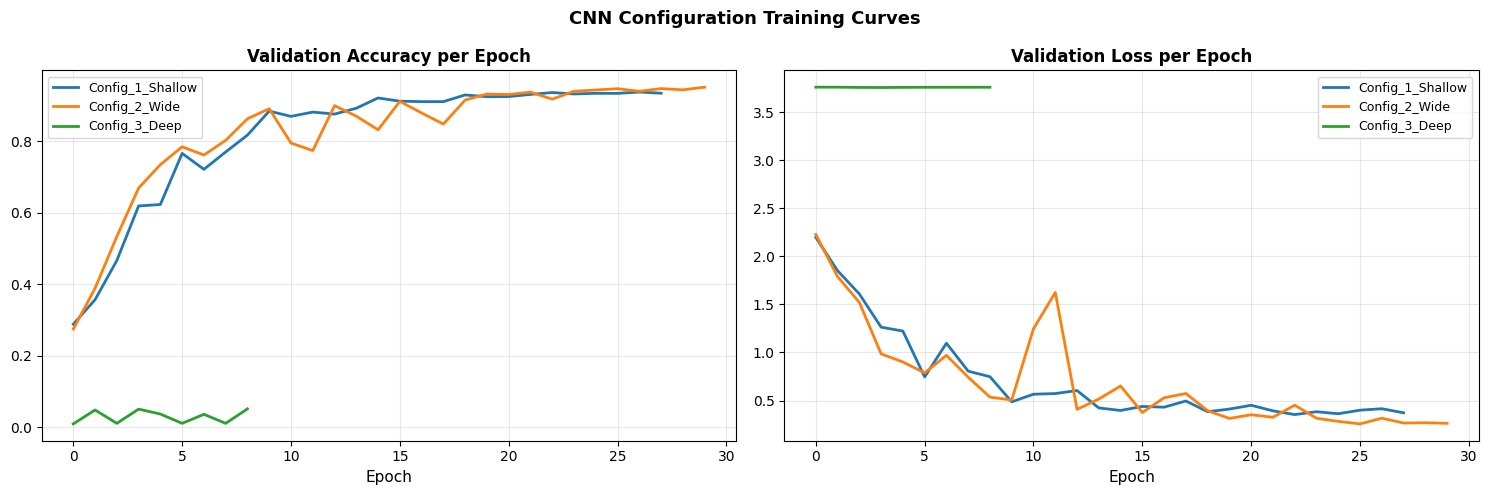

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for hist, cfg, color in zip(cnn_histories, cnn_configs, colors):
    lbl = cfg['name']
    axes[0].plot(hist.history['val_accuracy'], label=lbl, color=color, lw=2)
    axes[1].plot(hist.history['val_loss'],     label=lbl, color=color, lw=2)

for ax, title in zip(axes, ["Validation Accuracy per Epoch",
                              "Validation Loss per Epoch"]):
    ax.set_xlabel("Epoch", fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle("CNN Configuration Training Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("cnn_training_curves.png", dpi=150)
plt.show()


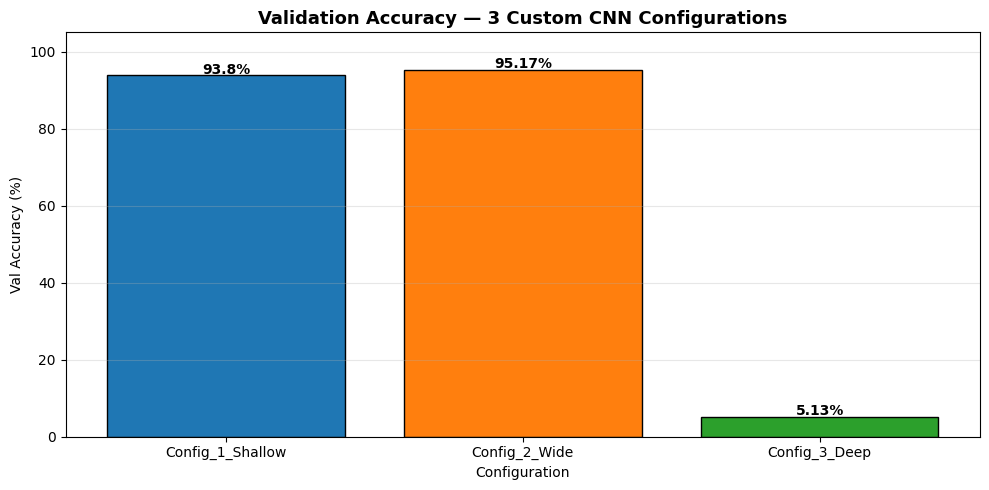

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_cnn['Model Configuration'], df_cnn['Best Val Accuracy (%)'],
              color=colors, edgecolor='black')
ax.set_ylim(0, 105)
ax.set_title("Validation Accuracy — 3 Custom CNN Configurations",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Configuration"); ax.set_ylabel("Val Accuracy (%)")
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("cnn_accuracy_comparison.png", dpi=150)
plt.show()


In [109]:

print("  SECTION 5 : TRANSFER LEARNING")

def make_tl_generators(preprocess_fn):
    train_dg = ImageDataGenerator(
        preprocessing_function=preprocess_fn, # Fixes the scale mismatch
        rotation_range=15, width_shift_range=0.10,
        height_shift_range=0.10, zoom_range=0.10,
        brightness_range=[0.5,1.5], validation_split=0.20
    )
    val_dg = ImageDataGenerator(preprocessing_function=preprocess_fn, validation_split=0.20)
    
    tg = train_dg.flow_from_directory(TRAIN_DIR, target_size=(64, 64), batch_size=32, class_mode='categorical', subset='training', seed=42)
    vg = val_dg.flow_from_directory(TRAIN_DIR, target_size=(64, 64), batch_size=32, class_mode='categorical', subset='validation', seed=42, shuffle=False)
    
    # Test generator
    df_test = pd.read_csv(TEST_CSV)
    df_test['ClassId'] = df_test['ClassId'].astype(str)
    test_dg = ImageDataGenerator(preprocessing_function=preprocess_fn)
    eg = test_dg.flow_from_dataframe(dataframe=df_test, directory=BASE_DIR, x_col='Path', y_col='ClassId', target_size=(64, 64), batch_size=32, class_mode='categorical', shuffle=False)
    return tg, vg, eg

mn_train_gen, mn_val_gen, mn_test_gen = make_tl_generators(mb_preprocess)
rn_train_gen, rn_val_gen, rn_test_gen = make_tl_generators(rn_preprocess)


  SECTION 5 : TRANSFER LEARNING
Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.
Found 12630 validated image filenames belonging to 43 classes.
Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.
Found 12630 validated image filenames belonging to 43 classes.


In [119]:
def build_finetuned_model(base_fn, model_name, unfreeze_layers):
    inputs = layers.Input(shape=(64, 64, 3))
    base = base_fn(include_top=False, weights='imagenet', input_shape=(64, 64, 3))
    
    # FINE-TUNING: Unfreeze the top layers as required by the PDF
    base.trainable = True
    for layer in base.layers[:-unfreeze_layers]:
        layer.trainable = False
        
    # CRITICAL: training=False keeps BatchNormalization statistics stable
    x = base(inputs, training=False)
    
    # The exact lightweight head specified in the project PDF
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = models.Model(inputs, outputs, name=model_name)
    # Use a very low learning rate (1e-4) so we don't destroy the unfreezed weights
    model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

pdf_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
]


In [120]:
print("\n──────── MobileNetV2 ────────")
mobilenet_model = build_finetuned_model(MobileNetV2, 'MobileNetV2_ADAS', unfreeze_layers=30)
mobilenet_model.summary()

t0 = time.time()
mb_history = mobilenet_model.fit(
    mn_train_gen, validation_data=mn_val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=pdf_callbacks,
    verbose=1
)
mb_total_min = (time.time() - t0) / 60
mobilenet_model.save("mobilenet_best.keras")
print(f"\n MobileNetV2 saved — total time: {mb_total_min:.1f} min")
print(f"   Best Val Acc: {max(mb_history.history['val_accuracy'])*100:.2f}%")



──────── MobileNetV2 ────────


Model: "MobileNetV2_ADAS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_83 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_31     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,499 (9.26 MB)

 Trainable params: 1,695,915 (6.47 MB)

 Non-trainable params: 731,584 (2.79 MB)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 106s 94ms/step - accuracy: 0.1916 - loss: 3.1617 - val_accuracy: 0.3867 - val_loss: 2.2736
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.5331 - loss: 1.4233 - val_accuracy: 0.4947 - val_loss: 1.8019
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 79s 81ms/step - accuracy: 0.6474 - loss: 0.9758 - val_accuracy: 0.5407 - val_loss: 1.6153
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 80s 82ms/step - accuracy: 0.7126 - loss: 0.7412 - val_accuracy: 0.5650 - val_loss: 1.5943
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 77s 78ms/step - accuracy: 0.7655 - loss: 0.5896 - val_accuracy: 0.6171 - val_loss: 1.3924
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 76s 78ms/step - accuracy: 0.7930 - loss: 0.4951 - val_accuracy: 0.6091 - val_loss: 1.5640
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 77s 79ms/step - accuracy: 0.8184 - loss: 0.4363 - val_accuracy: 0.5981 - val_loss: 1.5226
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 80s 82ms/step - accuracy: 0.8343 - loss: 0.4020 -

In [122]:
print("\n──────── ResNet50 ────────")
resnet_model = build_finetuned_model(ResNet50, 'ResNet50_ADAS', unfreeze_layers=40)
resnet_model.summary()

t0 = time.time()
rn_history = resnet_model.fit(
    rn_train_gen, validation_data=rn_val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=pdf_callbacks,
    verbose=1
)
rn_total_min = (time.time() - t0) / 60
resnet_model.save("resnet_best.keras")
print(f"\n ResNet50 saved — total time: {rn_total_min:.1f} min")
print(f"   Best Val Acc: {max(rn_history.history['val_accuracy'])*100:.2f}%")


──────── ResNet50 ────────


Model: "ResNet50_ADAS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_87 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_33     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,855,531 (91.00 MB)

 Trainable params: 16,099,627 (61.42 MB)

 Non-trainable params: 7,755,904 (29.59 MB)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 112s 95ms/step - accuracy: 0.3757 - loss: 2.3342 - val_accuracy: 0.6708 - val_loss: 1.1329
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 80s 81ms/step - accuracy: 0.8082 - loss: 0.5060 - val_accuracy: 0.6805 - val_loss: 1.1580
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 80s 81ms/step - accuracy: 0.8856 - loss: 0.2804 - val_accuracy: 0.7286 - val_loss: 1.1115
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 79s 80ms/step - accuracy: 0.9135 - loss: 0.2227 - val_accuracy: 0.7502 - val_loss: 0.9849
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 79s 81ms/step - accuracy: 0.9353 - loss: 0.1637 - val_accuracy: 0.7414 - val_loss: 1.0653
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.9394 - loss: 0.1530 - val_accuracy: 0.7605 - val_loss: 1.0063
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.9542 - loss: 0.1138 - val_accuracy: 0.7491 - val_loss: 1.1244
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 80s 81ms/step - accuracy: 0.9563 - loss: 0.1080 -

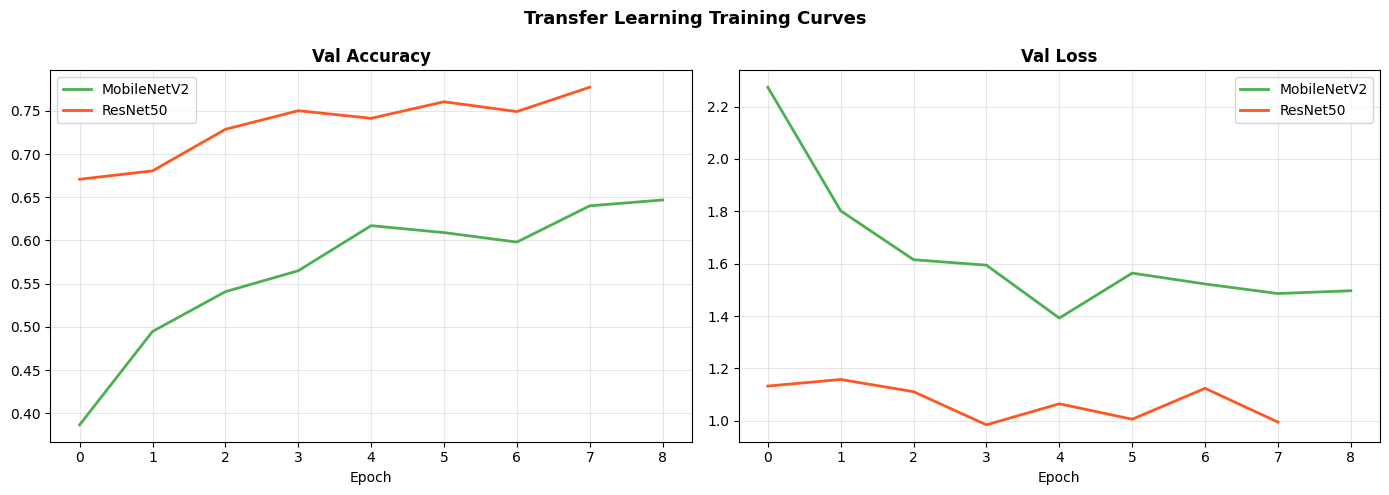

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mb_acc = mb_history.history['val_accuracy']
mb_los = mb_history.history['val_loss']
rn_acc = rn_history.history['val_accuracy']
rn_los = rn_history.history['val_loss']

axes[0].plot(mb_acc, label='MobileNetV2', color='#4CAF50', lw=2)
axes[0].plot(rn_acc, label='ResNet50',    color='#FF5722', lw=2)
axes[1].plot(mb_los, label='MobileNetV2', color='#4CAF50', lw=2)
axes[1].plot(rn_los, label='ResNet50',    color='#FF5722', lw=2)

for ax, t in zip(axes, ["Val Accuracy", "Val Loss"]):
    ax.set_title(t, fontsize=12, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Transfer Learning Training Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("tl_training_curves.png", dpi=150)
plt.show()

In [125]:
print("  SECTION 6 : SPEED vs. ACCURACY TRADE-OFF ANALYSIS")

def measure_inference_ms(model, generator, n=100):
    """
    Consistent methodology required by the project:
      1. Collect exactly n images from generator
      2. Warm-up pass (avoids JIT compilation overhead)
      3. Time model.predict() on the n images
      4. Return ms per image
    """
    generator.reset()
    batches = []
    collected = 0
    for bx, _ in generator:
        batches.append(bx)
        collected += len(bx)
        if collected >= n:
            break
    sample = np.vstack(batches)[:n]
    if len(sample) < n:
        sample = np.tile(sample, (n // len(sample) + 1, 1, 1, 1))[:n]

    _ = model.predict(sample[:10], verbose=0)          # warm-up
    t0 = time.time()
    _ = model.predict(sample, verbose=0, batch_size=n)
    return round((time.time() - t0) * 1000 / n, 3)

def get_size_mb(path):
    return round(os.path.getsize(path) / (1024 ** 2), 2) if os.path.exists(path) else 0.0

# Evaluate all three models on their respective test sets
# (Using the custom CNN loaded from Section 4)
custom_model = tf.keras.models.load_model(best_cnn_path)

print("Evaluating on test set…")
cnn_loss, cnn_acc = custom_model.evaluate(test_gen,     verbose=0)
mb_loss,  mb_acc  = mobilenet_model.evaluate(mn_test_gen, verbose=0)
rn_loss,  rn_acc  = resnet_model.evaluate(rn_test_gen,   verbose=0)

print("Measuring inference times…")
cnn_ms = measure_inference_ms(custom_model,    test_gen)
mb_ms  = measure_inference_ms(mobilenet_model, mn_test_gen)
rn_ms  = measure_inference_ms(resnet_model,    rn_test_gen)

# Constructing the tradeoff DataFrame using the correct history variables
tradeoff_df = pd.DataFrame([
    {
        "Model":                   "Custom CNN",
        "Val Accuracy (%)":        round(best_cnn_val * 100, 2),
        "Test Accuracy (%)":       round(cnn_acc * 100, 2),
        "Inference Time (ms/img)": cnn_ms,
        "Model Size (MB)":         get_size_mb(best_cnn_path),
        "Training Time (min)":     "~varies"
    },
    {
        "Model":                   "MobileNetV2",
        "Val Accuracy (%)":        round(max(mb_history.history['val_accuracy'])*100, 2),
        "Test Accuracy (%)":       round(mb_acc * 100, 2),
        "Inference Time (ms/img)": mb_ms,
        "Model Size (MB)":         get_size_mb("mobilenet_best.keras"),
        "Training Time (min)":     round(mb_total_min, 1)
    },
    {
        "Model":                   "ResNet50",
        "Val Accuracy (%)":        round(max(rn_history.history['val_accuracy'])*100, 2),
        "Test Accuracy (%)":       round(rn_acc * 100, 2),
        "Inference Time (ms/img)": rn_ms,
        "Model Size (MB)":         get_size_mb("resnet_best.keras"),
        "Training Time (min)":     round(rn_total_min, 1)
    },
])

print("\n Speed vs. Accuracy Trade-off Comparison Table:")
print(tradeoff_df.to_string(index=False))

  SECTION 6 : SPEED vs. ACCURACY TRADE-OFF ANALYSIS
Evaluating on test set…
Measuring inference times…

 Speed vs. Accuracy Trade-off Comparison Table:
      Model  Val Accuracy (%)  Test Accuracy (%)  Inference Time (ms/img)  Model Size (MB) Training Time (min)
 Custom CNN             95.17              97.76                    5.130            25.27             ~varies
MobileNetV2             64.69              64.60                    0.681            22.79                12.3
   ResNet50             77.73              77.85                    0.849           214.50                11.2


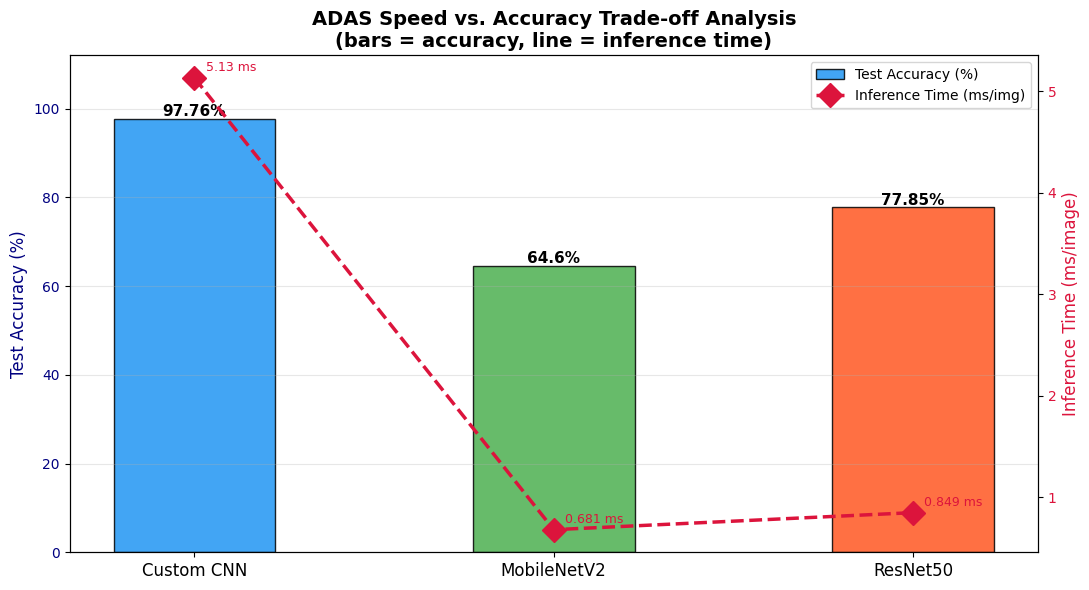

In [126]:
acc_vals   = tradeoff_df['Test Accuracy (%)'].astype(float).tolist()
infer_vals = tradeoff_df['Inference Time (ms/img)'].astype(float).tolist()
model_lbls = tradeoff_df['Model'].tolist()
x          = np.arange(3)
bar_colors = ['#2196F3', '#4CAF50', '#FF5722']

fig, ax1 = plt.subplots(figsize=(11, 6))
bars = ax1.bar(x, acc_vals, 0.45, color=bar_colors, alpha=0.85,
               edgecolor='black', label='Test Accuracy (%)')
ax1.set_ylabel("Test Accuracy (%)", color='navy', fontsize=12)
ax1.set_ylim(0, 112)
ax1.tick_params(axis='y', labelcolor='navy')
for b, v in zip(bars, acc_vals):
    ax1.text(b.get_x()+b.get_width()/2, v+0.5,
             f"{v}%", ha='center', fontweight='bold', fontsize=11)

ax2 = ax1.twinx()
ax2.plot(x, infer_vals, 'D--', color='crimson', lw=2.5,
         markersize=12, label='Inference Time (ms/img)')
for xi, yi in zip(x, infer_vals):
    ax2.annotate(f"{yi} ms", (xi, yi), textcoords="offset points",
                 xytext=(8, 5), fontsize=9, color='crimson')
ax2.set_ylabel("Inference Time (ms/image)", color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')

ax1.set_xticks(x); ax1.set_xticklabels(model_lbls, fontsize=12)
ax1.set_title("ADAS Speed vs. Accuracy Trade-off Analysis\n"
              "(bars = accuracy, line = inference time)",
              fontsize=14, fontweight='bold')
l1, n1 = ax1.get_legend_handles_labels()
l2, n2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, n1+n2, loc='upper right', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("tradeoff_dual_axis.png", dpi=150)
plt.show()

In [127]:
FINAL_MODEL_NAME = "MobileNetV2" if mb_acc >= rn_acc else "ResNet50"
FINAL_MODEL      = mobilenet_model if FINAL_MODEL_NAME == "MobileNetV2" else resnet_model
FINAL_TEST_GEN   = mn_test_gen     if FINAL_MODEL_NAME == "MobileNetV2" else rn_test_gen

print(f"Final model selected for Section 7: {FINAL_MODEL_NAME} "
      f"(Test Acc = {max(mb_acc,rn_acc)*100:.2f}%)")

Final model selected for Section 7: ResNet50 (Test Acc = 77.85%)


In [128]:

print("  SECTION 7 : MODEL EVALUATION")

FINAL_TEST_GEN.reset()
final_loss, final_acc = FINAL_MODEL.evaluate(FINAL_TEST_GEN, verbose=1)
print(f"\n Final Model ({FINAL_MODEL_NAME})")
print(f"   Test Accuracy : {final_acc*100:.2f}%")
print(f"   Test Loss     : {final_loss:.4f}")

  SECTION 7 : MODEL EVALUATION
395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.7782 - loss: 0.8411

 Final Model (ResNet50)
   Test Accuracy : 77.85%
   Test Loss     : 0.8480


In [130]:
FINAL_TEST_GEN.reset()
y_pred_prob = FINAL_MODEL.predict(FINAL_TEST_GEN, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = FINAL_TEST_GEN.classes[: len(y_pred)]

report = classification_report(
    y_true, y_pred,
    target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    digits=3
)
print(report)

395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step
                          precision    recall  f1-score   support

    Speed limit (20km/h)      0.123     0.117     0.120        60
    Speed limit (30km/h)      0.762     0.475     0.585       720
    Speed limit (50km/h)      0.913     0.974     0.943       660
    Speed limit (60km/h)      0.864     0.819     0.841       420
    Speed limit (70km/h)      0.996     0.968     0.982       690
    Speed limit (80km/h)      0.988     0.994     0.991       720
End speed limit (80km/h)      0.982     0.993     0.987       270
   Speed limit (100km/h)      1.000     0.962     0.981       210
   Speed limit (120km/h)      0.973     0.953     0.963       150
              No passing      0.997     0.936     0.966       360
     No passing veh>3.5t      0.911     0.867     0.888       390
            Right-of-way      0.469     0.500     0.484        60
           Priority road      0.540     0.573     0.556       750
                   Yield      0.

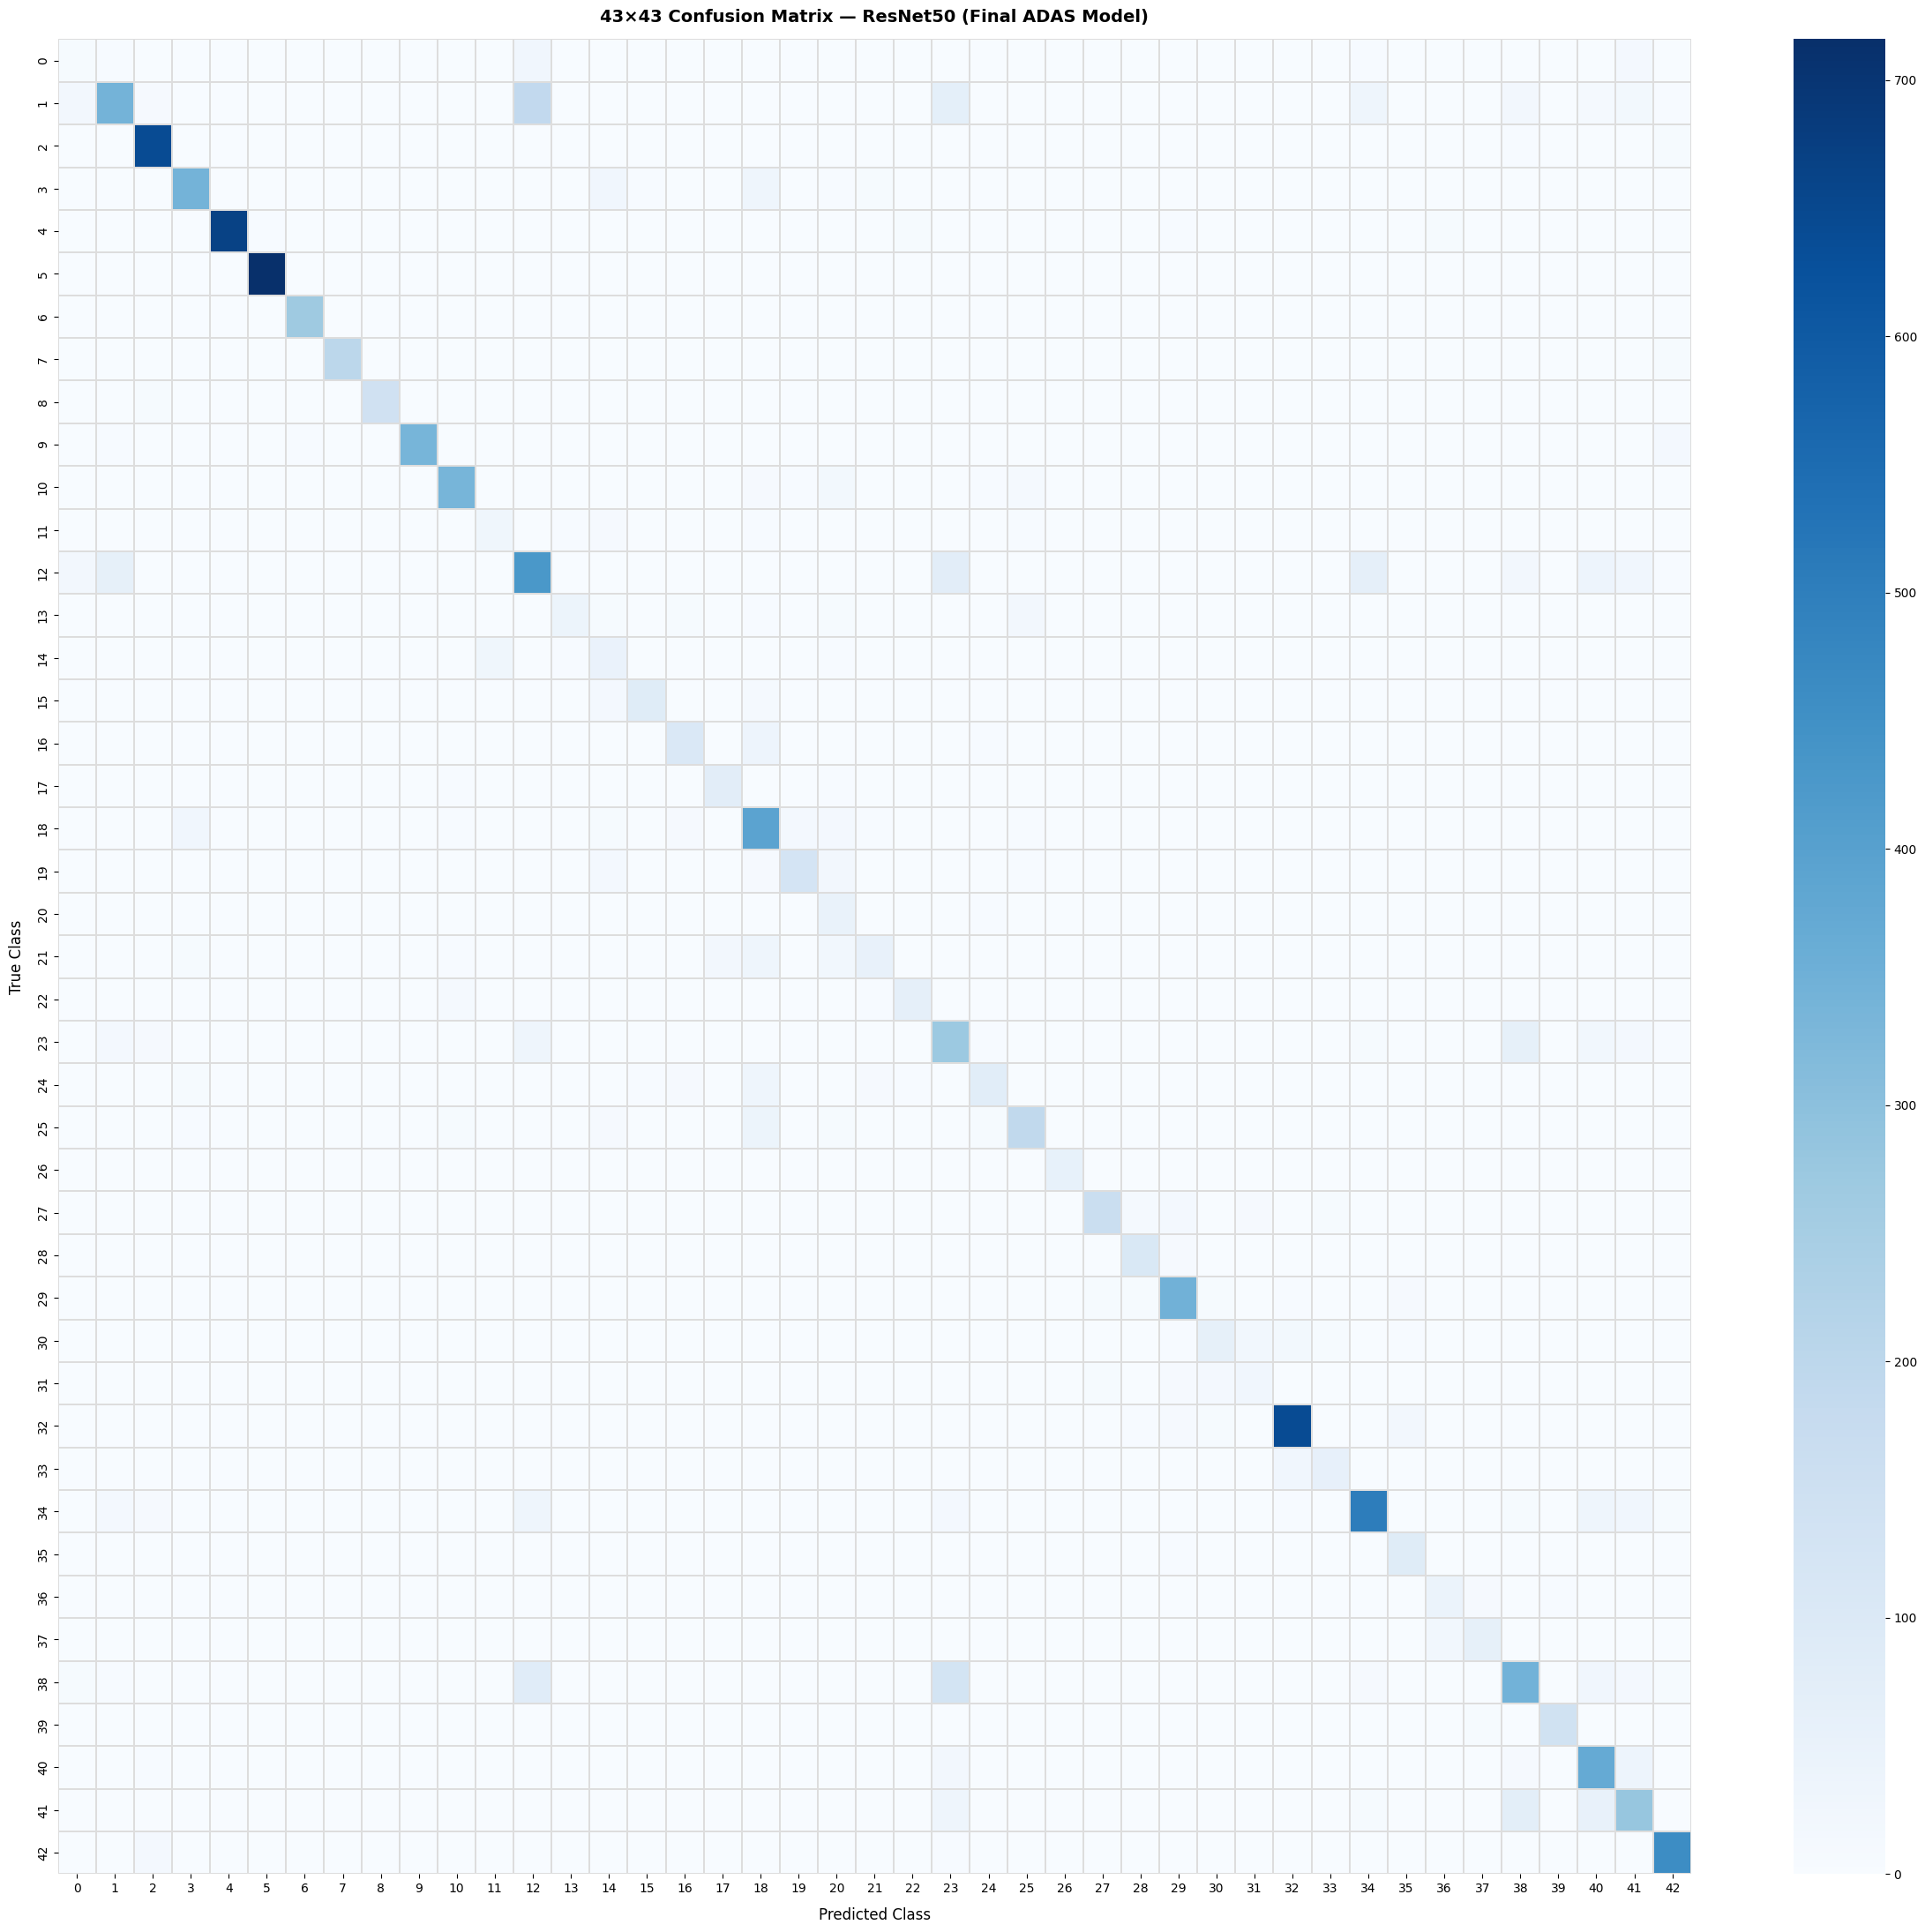

In [131]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(24, 22))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(NUM_CLASSES),
            yticklabels=range(NUM_CLASSES),
            linewidths=0.3, linecolor='#dddddd')
ax.set_xlabel("Predicted Class", fontsize=12, labelpad=10)
ax.set_ylabel("True Class",      fontsize=12, labelpad=10)
ax.set_title(f"43×43 Confusion Matrix — {FINAL_MODEL_NAME} (Final ADAS Model)",
             fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig("confusion_matrix_43x43.png", dpi=150)
plt.show()

In [132]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
r, c = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
print(f"\n  Most confused pair:")
print(f"   Class {r:2d} [{CLASS_NAMES[r]}]")
print(f"   → predicted as Class {c:2d} [{CLASS_NAMES[c]}]  ({cm_no_diag[r,c]} times)")
print("   Likely cause: similar colour and shape, differing only in subtle internal symbols.")


  Most confused pair:
   Class  1 [Speed limit (30km/h)]
   → predicted as Class 12 [Priority road]  (189 times)
   Likely cause: similar colour and shape, differing only in subtle internal symbols.


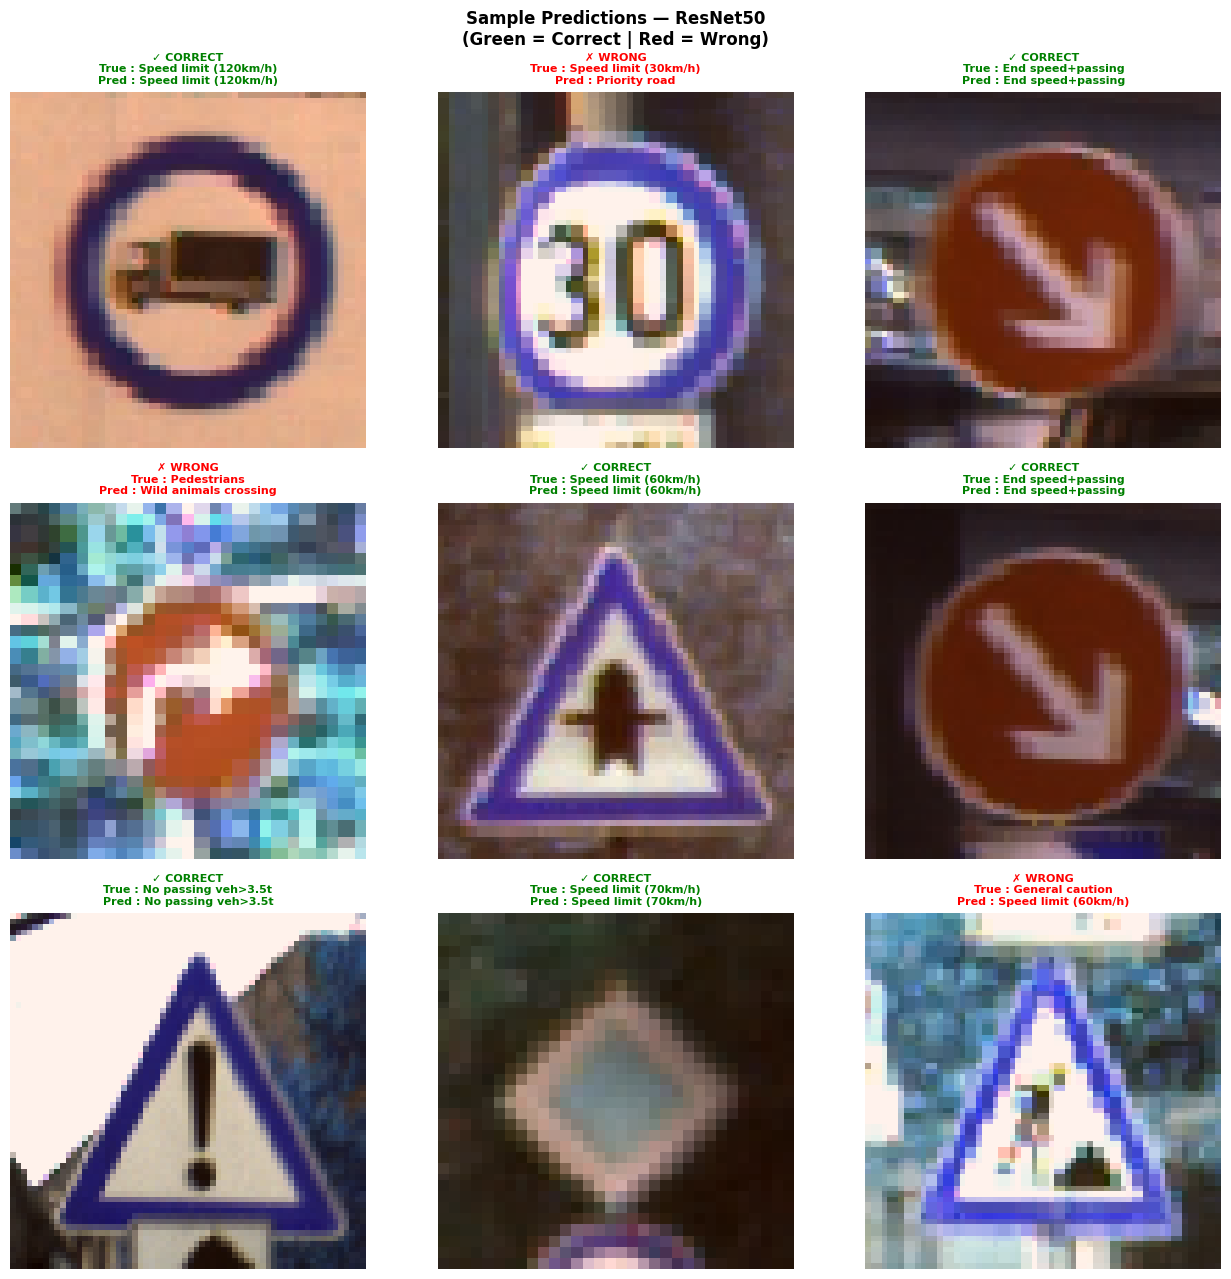

In [133]:
FINAL_TEST_GEN.reset()
batch_x, batch_y = next(FINAL_TEST_GEN)
preds = np.argmax(FINAL_MODEL.predict(batch_x[:9], verbose=0), axis=1)
trues = np.argmax(batch_y[:9], axis=1)

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
for i, ax in enumerate(axes.flat):
    # This line is crucial: it reverses any bizarre scaling (like [-1, 1]) 
    # back to [0, 1] so Matplotlib can actually display the image without distortion.
    disp = batch_x[i].copy()
    disp = (disp - disp.min()) / (disp.max() - disp.min() + 1e-8)
    ax.imshow(np.clip(disp, 0, 1))

    correct = trues[i] == preds[i]
    color   = 'green' if correct else 'red'
    label   = "✓ CORRECT" if correct else "✗ WRONG"
    ax.set_title(
        f"{label}\nTrue : {CLASS_NAMES[trues[i]][:22]}\n"
        f"Pred : {CLASS_NAMES[preds[i]][:22]}",
        color=color, fontsize=8, fontweight='bold'
    )
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3)

plt.suptitle(f"Sample Predictions — {FINAL_MODEL_NAME}\n"
             "(Green = Correct | Red = Wrong)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_predictions_grid.png", dpi=150)
plt.show()

In [138]:
print("  SECTION 8 : END-TO-END PIPELINE DEMONSTRATION")

if FINAL_MODEL_NAME == "ResNet50":
    PREPROCESS_FN = mb_preprocess
else:
    PREPROCESS_FN = rn_preprocess

def run_full_pipeline(image_input, model, preprocess_fn, class_names=CLASS_NAMES):
    """
    Complete two-stage ADAS pipeline required by the PDF:
      Stage 1 → detect_and_crop_sign()  (OpenCV colour-thresholding)
      Stage 2 → CNN classifier           (Fine-Tuned Transfer Learning Model)
    """
    if isinstance(image_input, str):
        img_bgr = cv2.imread(image_input)
    else:
        img_bgr = image_input.copy()

    # Stage 1 — Detection
    result = detect_and_crop_sign(img_bgr)
    if result is None:
        return None, None, {"error": "No sign detected"}

    img_bgr, (x, y, w, h), cropped = result
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Annotate bounding box on a copy
    annotated = img_rgb.copy()
    cv2.rectangle(annotated, (x, y), (x+w, y+h), (0, 255, 0), 3)

    # Stage 2 — Classification
    # CRITICAL: We must use the correct preprocessor here!
    inp   = preprocess_fn(cropped.astype(np.float32))
    probs = model.predict(np.expand_dims(inp, 0), verbose=0)[0]
    top3  = probs.argsort()[-3:][::-1]

    prediction = {
        "class_id":   int(top3[0]),
        "class_name": class_names[top3[0]],
        "confidence": float(probs[top3[0]]),
        "top3": [(class_names[i], round(float(probs[i])*100, 1)) for i in top3]
    }

    # Write label on the annotated image
    lbl = f"{prediction['class_name'][:20]}  {prediction['confidence']*100:.0f}%"
    cv2.putText(annotated, lbl, (x, max(y-9, 14)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0,255,0), 2)
    return annotated, cropped, prediction

  SECTION 8 : END-TO-END PIPELINE DEMONSTRATION



Test case 1 — True class: Stop
  Predicted  : Slippery road  (38.7%)
  Top-3      : [('Slippery road', 38.7), ('Road work', 7.8), ('Roundabout mandatory', 6.7)]

Test case 2 — True class: No entry
  Predicted  : Slippery road  (32.7%)
  Top-3      : [('Slippery road', 32.7), ('Road work', 11.0), ('Veh>3.5t prohibited', 5.9)]


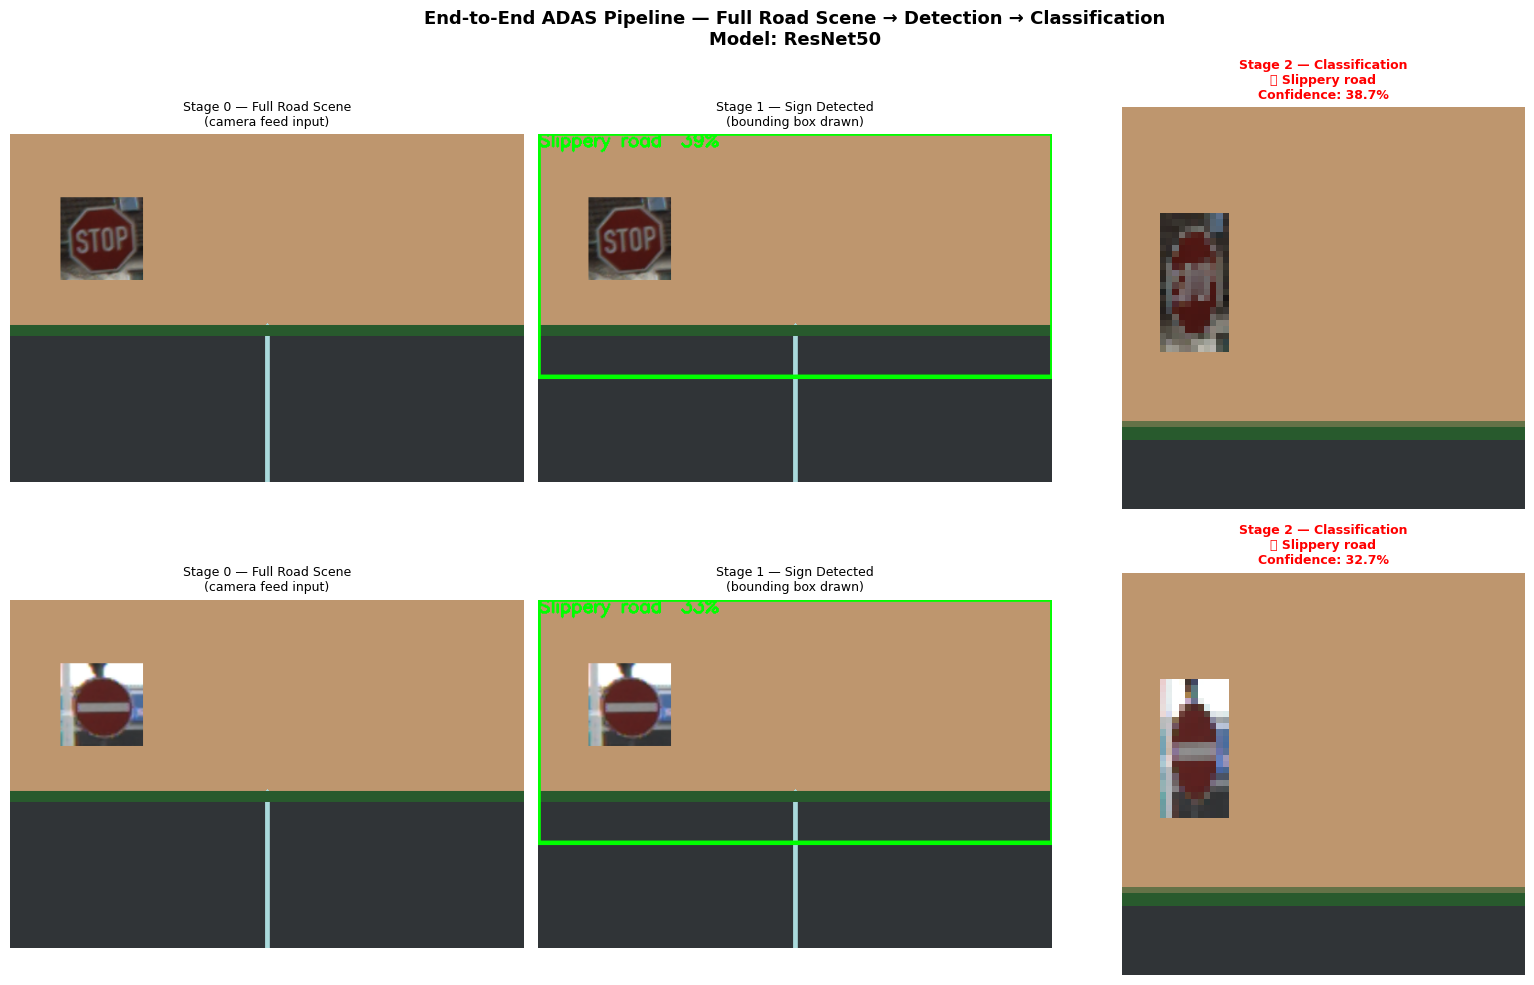

In [139]:
demo_classes = [14, 17]   # Stop, No Entry
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row, cls_id in enumerate(demo_classes):
    scene_bgr, _ = make_road_scene(cls_id)
    annotated, cropped, pred = run_full_pipeline(
        scene_bgr, FINAL_MODEL, PREPROCESS_FN)

    orig_rgb = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)

    axes[row, 0].imshow(orig_rgb)
    axes[row, 0].set_title("Stage 0 — Full Road Scene\n(camera feed input)", fontsize=9)
    axes[row, 0].axis('off')

    if annotated is not None:
        axes[row, 1].imshow(annotated)
        axes[row, 1].set_title("Stage 1 — Sign Detected\n(bounding box drawn)", fontsize=9)
        axes[row, 1].axis('off')

        correct = pred["class_id"] == cls_id
        color   = 'green' if correct else 'red'
        axes[row, 2].imshow(cropped)
        axes[row, 2].set_title(
            f"Stage 2 — Classification\n"
            f"{'✅' if correct else '❌'} {pred['class_name'][:24]}\n"
            f"Confidence: {pred['confidence']*100:.1f}%",
            fontsize=9, color=color, fontweight='bold'
        )
        axes[row, 2].axis('off')

        print(f"\nTest case {row+1} — True class: {CLASS_NAMES[cls_id]}")
        print(f"  Predicted  : {pred['class_name']}  ({pred['confidence']*100:.1f}%)")
        print(f"  Top-3      : {pred['top3']}")
    else:
        axes[row, 1].text(0.5,0.5,"Detection failed", ha='center',va='center',color='red',fontsize=12)
        axes[row, 2].text(0.5,0.5,"N/A", ha='center',va='center',color='red',fontsize=12)

plt.suptitle(
    "End-to-End ADAS Pipeline — Full Road Scene → Detection → Classification\n"
    f"Model: {FINAL_MODEL_NAME}",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig("e2e_pipeline_demo.png", dpi=150)
plt.show()